<a href="https://colab.research.google.com/github/Sanskar-CB/smart-traffic-management-system/blob/main/Smart_traffic_management_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPOSITORY/blob/main/YOUR_NOTEBOOK.ipynb)


In [1]:
# Install OpenCV and plotting utilities
!pip install -q opencv-python-headless numpy pandas matplotlib seaborn

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("✅ Dependencies successfully loaded!")

✅ Dependencies successfully loaded!


In [2]:
np.random.seed(42)

def simulate_intersection_traffic():
    """
    Simulates real-time vehicle counts across a 4-way intersection.
    Returns counts for Cars, Buses, Trucks, and Motorcycles per lane.
    """
    lanes = ['North', 'South', 'East', 'West']
    traffic_data = []

    for lane in lanes:
        cars = np.random.randint(2, 25)
        buses = np.random.randint(0, 5)
        trucks = np.random.randint(0, 4)
        motorcycles = np.random.randint(1, 10)

        # Weighted passenger/space units (PCU - Passenger Car Unit)
        # Buses and Trucks take up more physical road space
        pcu_score = (cars * 1.0) + (buses * 2.5) + (trucks * 3.0) + (motorcycles * 0.5)

        traffic_data.append({
            'lane': lane,
            'cars': cars,
            'buses': buses,
            'trucks': trucks,
            'motorcycles': motorcycles,
            'total_vehicles': cars + buses + trucks + motorcycles,
            'pcu_score': round(pcu_score, 1)
        })

    return pd.DataFrame(traffic_data)

intersection_df = simulate_intersection_traffic()
print("📊 Simulated Real-Time Intersection Data:")
intersection_df

📊 Simulated Real-Time Intersection Data:


,lane,cars,buses,trucks,motorcycles,total_vehicles,pcu_score
0,North,8,3,0,8,19,19.5
1,South,22,1,2,7,32,34.0
2,East,12,2,3,5,22,28.5
3,West,5,2,1,5,13,15.5


In [3]:
def calculate_dynamic_green_time(df, min_green=10, max_green=60):
    """
    Dynamically allocates green light duration proportional to lane congestion (PCU Score).
    """
    total_pcu = df['pcu_score'].sum()

    # Calculate proportional green light duration (in seconds)
    df['green_time_sec'] = ((df['pcu_score'] / total_pcu) * (max_green * 2)).round().astype(int)

    # Enforce minimum and maximum safety bounds
    df['green_time_sec'] = df['green_time_sec'].clip(lower=min_green, upper=max_green)

    # Assign Signal Priority Ranking
    df['priority_rank'] = df['pcu_score'].rank(ascending=False, method='min').astype(int)
    df = df.sort_values(by='priority_rank').reset_index(drop=True)

    return df

optimized_signals = calculate_dynamic_green_time(intersection_df)
print("🚦 Dynamic Signal Allocation Schedule:")
optimized_signals[['priority_rank', 'lane', 'total_vehicles', 'pcu_score', 'green_time_sec']]

🚦 Dynamic Signal Allocation Schedule:


,priority_rank,lane,total_vehicles,pcu_score,green_time_sec
0,1,South,32,34.0,42
1,2,East,22,28.5,35
2,3,North,19,19.5,24
3,4,West,13,15.5,19


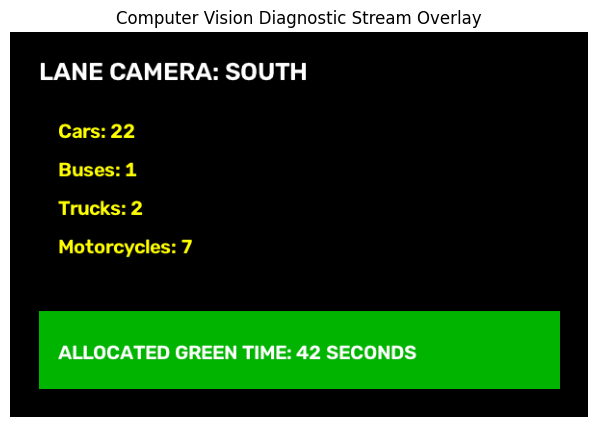

In [4]:
def draw_traffic_analysis_frame(lane_name, vehicle_counts, green_time):
    """
    Generates a visual diagnostic frame overlay matching CV camera streams.
    """
    # Create blank dark image frame
    frame = np.zeros((400, 600, 3), dtype=np.uint8)

    # Draw header text
    cv2.putText(frame, f"LANE CAMERA: {lane_name.upper()}", (30, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)

    # Display vehicle counts
    y_offset = 110
    for vehicle, count in vehicle_counts.items():
        cv2.putText(frame, f"{vehicle.capitalize()}: {count}", (50, y_offset),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
        y_offset += 40

    # Draw Green Light Box indicator
    cv2.rectangle(frame, (30, 290), (570, 370), (0, 180, 0), -1)
    cv2.putText(frame, f"ALLOCATED GREEN TIME: {green_time} SECONDS", (50, 340),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return frame

# Render preview for the highest priority lane
top_lane = optimized_signals.iloc[0]
counts = {
    'cars': top_lane['cars'],
    'buses': top_lane['buses'],
    'trucks': top_lane['trucks'],
    'motorcycles': top_lane['motorcycles']
}

frame_img = draw_traffic_analysis_frame(top_lane['lane'], counts, top_lane['green_time_sec'])

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(frame_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Computer Vision Diagnostic Stream Overlay")
plt.show()

/tmp/ipykernel_1078/1683888142.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=optimized_signals, x='lane', y='pcu_score', palette='Reds_d', ax=axes[0])
/tmp/ipykernel_1078/1683888142.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=optimized_signals, x='lane', y='green_time_sec', palette='Greens_d', ax=axes[1])


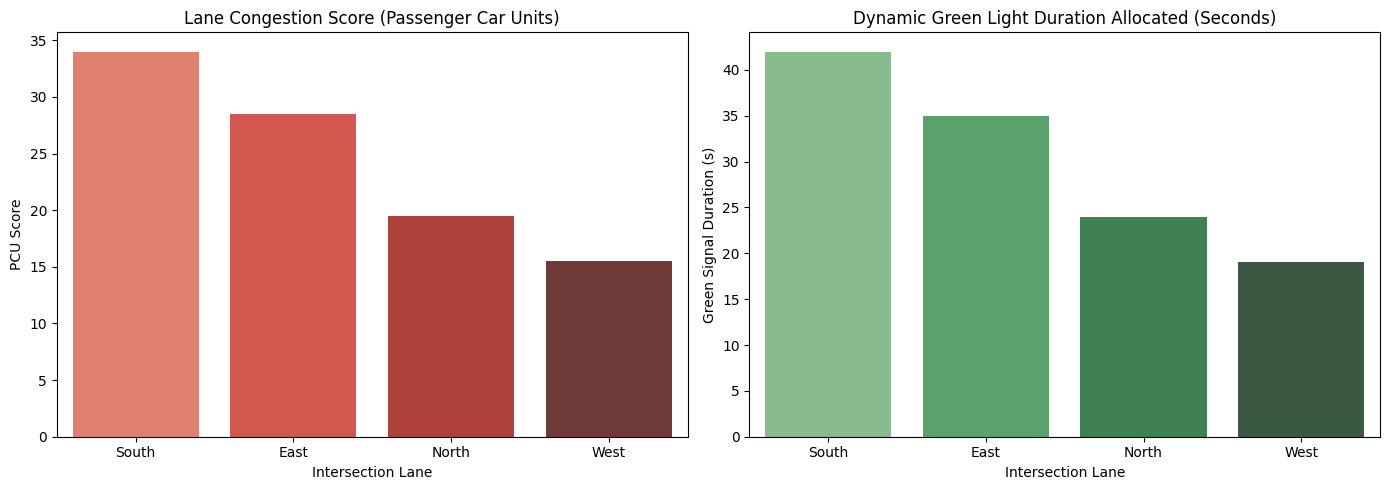

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Congestion Units by Lane
sns.barplot(data=optimized_signals, x='lane', y='pcu_score', palette='Reds_d', ax=axes[0])
axes[0].set_title('Lane Congestion Score (Passenger Car Units)')
axes[0].set_ylabel('PCU Score')
axes[0].set_xlabel('Intersection Lane')

# 2. Dynamic Green Time Allocation
sns.barplot(data=optimized_signals, x='lane', y='green_time_sec', palette='Greens_d', ax=axes[1])
axes[1].set_title('Dynamic Green Light Duration Allocated (Seconds)')
axes[1].set_ylabel('Green Signal Duration (s)')
axes[1].set_xlabel('Intersection Lane')

plt.tight_layout()
plt.show()

In [6]:
def run_traffic_light_controller(df):
    """
    Executes real-time signal phase rotation according to calculated priority.
    """
    print("\n🚥 Starting Smart Traffic Controller Signal Cycle...\n")
    for idx, row in df.iterrows():
        print(f"🟢 [GREEN LIGHT ON] -> Lane: {row['lane']} | Duration: {row['green_time_sec']}s | Vehicles Waiting: {row['total_vehicles']}")
        time.sleep(1)  # Simulated timer step
        print(f"🟡 [YELLOW LIGHT]   -> Lane: {row['lane']} | Transitioning...")
        print(f"🔴 [RED LIGHT ON]   -> Lane: {row['lane']}\n" + "-"*45)

run_traffic_light_controller(optimized_signals)


🚥 Starting Smart Traffic Controller Signal Cycle...

🟢 [GREEN LIGHT ON] -> Lane: South | Duration: 42s | Vehicles Waiting: 32
🟡 [YELLOW LIGHT]   -> Lane: South | Transitioning...
🔴 [RED LIGHT ON]   -> Lane: South
---------------------------------------------
🟢 [GREEN LIGHT ON] -> Lane: East | Duration: 35s | Vehicles Waiting: 22
🟡 [YELLOW LIGHT]   -> Lane: East | Transitioning...
🔴 [RED LIGHT ON]   -> Lane: East
---------------------------------------------
🟢 [GREEN LIGHT ON] -> Lane: North | Duration: 24s | Vehicles Waiting: 19
🟡 [YELLOW LIGHT]   -> Lane: North | Transitioning...
🔴 [RED LIGHT ON]   -> Lane: North
---------------------------------------------
🟢 [GREEN LIGHT ON] -> Lane: West | Duration: 19s | Vehicles Waiting: 13
🟡 [YELLOW LIGHT]   -> Lane: West | Transitioning...
🔴 [RED LIGHT ON]   -> Lane: West
---------------------------------------------
